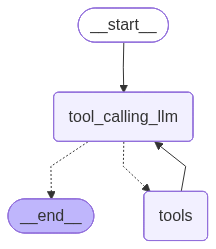

In [1]:
from typing import Annotated # add contextual meta-data

from typing_extensions import TypedDict

## StateGraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages

from IPython.display import Image, display

# memory
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# llm

llm = ChatGroq(model="openai/gpt-oss-20b")

# tool 1
from langchain_tavily import TavilySearch
tool = TavilySearch(max_results = 1)

# tool 2 (custom)

def multiply(a: int, b: int) -> int:
    """Multiply a and b
    
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """

    return a * b

tools = [tool, multiply]
llm_with_tools = llm.bind_tools(tools)

# Node definition

class State(TypedDict):
    messages: Annotated[list, add_messages]

def tool_calling_llm(state: State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

### GRAPH

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add the edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", # from tool_calling_llm tool
    # If the latest message from assistant is a tool call -> tools_condiiton routes to tools

    # If the latest message (result) from assistant is not a tool call -> tools_condition roites to END (by default, no need to add it ourselves)
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

# Now we have conditional edges

graph = builder.compile(checkpointer = memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [2]:
# We now create a thread-ID

config1 = {
    "configurable": {"thread_id":"1"} # unique thread id
}

response = graph.invoke({"messages":"Hi! My name is Abdul"}, config = config1)

print(response["messages"][-1].content)

Hello Abdul! Nice to meet you. How can I help you today?


In [3]:
response = graph.invoke({"messages":"Do you know my name"}, config = config1)

print(response["messages"][-1].content)

Yes, you mentioned your name is Abdul. How can I assist you further?


In [4]:
config2 = {
    "configurable": {"thread_id":"2"} # unique thread id
}

response = graph.invoke({"messages":"Do you know my name?"}, config = config2)
print(response["messages"][-1].content)

I don’t have any personal information about you unless you share it. What’s your name?


In [6]:
response = graph.invoke({"messages": "Tell me the latest AI news of 2026"}, config = config1)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi! My name is Abdul
================================== Ai Message ==================================

Hello Abdul! Nice to meet you. How can I help you today?
================================ Human Message =================================

Do you know my name
================================== Ai Message ==================================

Yes, you mentioned your name is Abdul. How can I assist you further?
================================ Human Message =================================

Tell me the latest AI news of 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_18bfda14-fcaf-48a4-8894-e5b726c7b4a0)
 Call ID: fc_18bfda14-fcaf-48a4-8894-e5b726c7b4a0
  Args:
    query: latest AI news 2026
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"q

# Streaming

In [2]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [2]:
def superbot(state: State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

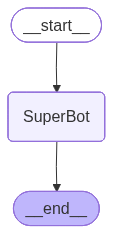

In [5]:
graph = StateGraph(State)

graph.add_node("SuperBot", superbot)

graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer = memory)

display(Image(graph_builder.get_graph().draw_mermaid_png()))